<a href="https://colab.research.google.com/github/gopaps/MachineLearning/blob/main/TUGAS%20PERBAIKAN/Chapter_2_Perbaikan_Anda_Figo_Haq.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Chapter 2 membahas konsep dasar dari pembelajaran terawasi (supervised learning) dalam machine learning, dimulai dengan pentingnya memahami kompleksitas model dan generalisasi. Generalisasi adalah kemampuan model untuk bekerja baik pada data baru yang belum pernah dilihat sebelumnya. Dalam konteks ini, konsep underfitting dan overfitting diperkenalkan. Underfitting terjadi ketika model terlalu sederhana untuk menangkap pola dalam data pelatihan, sedangkan overfitting terjadi ketika model terlalu fokus pada data pelatihan hingga gagal menangkap pola umum.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import torch

In [8]:
# Periksa apakah GPU tersedia
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("GPU tersedia. Menggunakan:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("GPU tidak tersedia. Menggunakan CPU.")


GPU tersedia. Menggunakan: Tesla T4


In [9]:
# Membuat dataset simulasi untuk klasifikasi
X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, n_redundant=5, random_state=42)

# Konversi data menjadi tensor torch untuk potensi penggunaan GPU
X_tensor = torch.tensor(X, dtype=torch.float32, device=device)
y_tensor = torch.tensor(y, dtype=torch.long, device=device)

# Membagi data menjadi set pelatihan dan pengujian
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


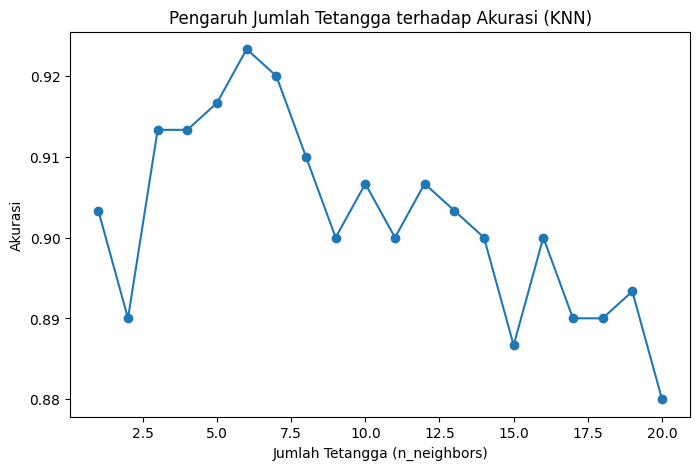

In [10]:
# Eksperimen Overfitting dan Underfitting dengan KNN
plt.figure(figsize=(8, 5))
accuracies = []
for n in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=n)
    knn.fit(X_train, y_train)
    y_pred_knn = knn.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred_knn))

plt.plot(range(1, 21), accuracies, marker='o')
plt.xlabel("Jumlah Tetangga (n_neighbors)")
plt.ylabel("Akurasi")
plt.title("Pengaruh Jumlah Tetangga terhadap Akurasi (KNN)")
plt.show()

In [11]:
# KNN dengan jumlah tetangga yang berbeda
for n in [1, 5, 10]:
    knn = KNeighborsClassifier(n_neighbors=n)
    knn.fit(X_train, y_train)
    y_pred_knn = knn.predict(X_test)
    accuracy_knn = accuracy_score(y_test, y_pred_knn)
    print(f"Akurasi KNN (n_neighbors={n}): {accuracy_knn * 100:.2f}%")


Akurasi KNN (n_neighbors=1): 90.33%
Akurasi KNN (n_neighbors=5): 91.67%
Akurasi KNN (n_neighbors=10): 90.67%


In [12]:
# Logistic Regression tanpa scaling
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)
accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
print(f"Akurasi Logistic Regression tanpa scaling: {accuracy_logreg * 100:.2f}%")


Akurasi Logistic Regression tanpa scaling: 81.00%


In [13]:
# Logistic Regression dengan scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg_scaled = LogisticRegression(max_iter=1000, random_state=42)
logreg_scaled.fit(X_train_scaled, y_train)
y_pred_logreg_scaled = logreg_scaled.predict(X_test_scaled)
accuracy_logreg_scaled = accuracy_score(y_test, y_pred_logreg_scaled)
print(f"Akurasi Logistic Regression dengan scaling: {accuracy_logreg_scaled * 100:.2f}%")


Akurasi Logistic Regression dengan scaling: 81.00%


In [14]:
# Evaluasi model Logistic Regression (dengan scaling)
print("Confusion Matrix Logistic Regression (dengan scaling):")
print(confusion_matrix(y_test, y_pred_logreg_scaled))
print("Classification Report Logistic Regression (dengan scaling):")
print(classification_report(y_test, y_pred_logreg_scaled))

Confusion Matrix Logistic Regression (dengan scaling):
[[122  29]
 [ 28 121]]
Classification Report Logistic Regression (dengan scaling):
              precision    recall  f1-score   support

           0       0.81      0.81      0.81       151
           1       0.81      0.81      0.81       149

    accuracy                           0.81       300
   macro avg       0.81      0.81      0.81       300
weighted avg       0.81      0.81      0.81       300



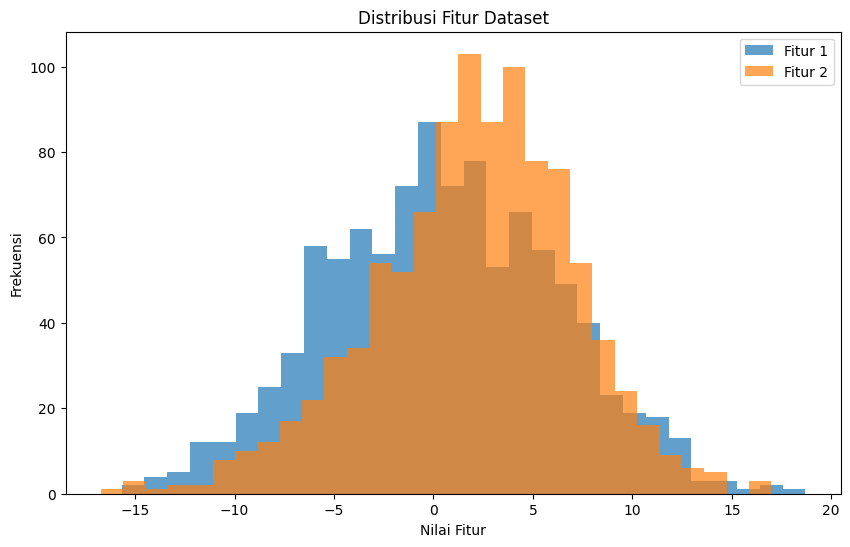

In [15]:
# Visualisasi distribusi salah satu fitur utama
plt.figure(figsize=(10, 6))
plt.hist(X[:, 0], bins=30, alpha=0.7, label='Fitur 1')
plt.hist(X[:, 1], bins=30, alpha=0.7, label='Fitur 2')
plt.xlabel("Nilai Fitur")
plt.ylabel("Frekuensi")
plt.title("Distribusi Fitur Dataset")
plt.legend()
plt.show()

Selain itu, chapter ini juga menjelaskan berbagai jenis algoritma supervised learning untuk klasifikasi dan regresi, termasuk kelebihan, kekurangan, serta cara mengontrol kompleksitas model. Misalnya, k-Nearest Neighbors (k-NN) cocok untuk dataset kecil, mudah dipahami, namun rentan terhadap noise. Logistic Regression sering digunakan sebagai baseline model, terutama pada data berskala besar. Algoritma lain seperti decision trees, random forests, support vector machines (SVMs), hingga neural networks juga dibahas dengan penekanan pada parameter yang harus diatur agar model bekerja optimal.

Di akhir bab, ditekankan pentingnya memulai dengan model yang sederhana, seperti linear models atau k-NN, sebelum beralih ke algoritma yang lebih kompleks. Hal ini membantu kita memahami data lebih baik sebelum mencoba algoritma seperti random forests, gradient boosted trees, atau neural networks. Dengan eksperimen pada dataset bawaan scikit-learn, seperti digits untuk klasifikasi atau boston_housing untuk regresi, kita dapat mengeksplorasi algoritma yang sesuai dengan kebutuhan serta mendapatkan wawasan lebih tentang performa dan sensitivitasnya terhadap data.